# External emotion evaluation — test split only

Breaks the internal-encoder circularity flagged by reviewer: evaluates generated videos with **classifiers never involved in training or model selection**.

**Protocol:**
1. For each fine-tuned checkpoint (baseline + ablation configs), generate full-length videos from **test split** audio.
2. Run independent classifiers — all trained on non-RAVDESS data — on the generated frames.
3. Compare external accuracy / F1 against the ground-truth emotion label.
4. Report Δ external-F1 vs baseline with statistical significance.

**External models:**
- **Video**: `dima806/facial_emotions_image_detection` — ViT trained on an FER-derived face-emotion corpus (7 classes: angry, disgust, fear, happy, neutral, sad, surprise). Chosen specifically **because it was not trained on AffectNet** and shares no weights with any encoder touched during `02_train_encoders_*` / `04_finetune_wav2lip` / `04b_wav2lip_loss_ablation`. Earlier drafts used `trpakov/vit-face-expression` (AffectNet ViT); that model was later evaluated as a video-encoder baseline in `02_train_encoders_6emotions.ipynb`, so reusing it here would reintroduce the exact circularity the reviewer flagged.
- **Audio (optional dim.)**: `audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim` — MSP-Podcast dimensional emotion (arousal/dominance/valence) for cross-modal sanity check.

Neither was used at any stage of training or model selection.

In [1]:
!pip install -q transformers librosa scipy scikit-learn Pillow

In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import sys
sys.path.insert(0, "/content")
sys.path.insert(0, "/content/Wav2Lip")

import json
import warnings
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from PIL import Image
from scipy import stats
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from transformers import (
    AutoImageProcessor, AutoModelForImageClassification,
    AutoFeatureExtractor, AutoModel,
)

from models.wav2lip import Wav2Lip as Wav2LipModel

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
METADATA = "/content/processed_data/metadata.json"
WAV2LIP_CKPT = "/content/Wav2Lip/checkpoints/wav2lip.pth"

ABLATION_DIR = Path("/content/wav2lip_loss_ablation")
ORIG_DIR = Path("/content/wav2lip_finetuned")
OUT_DIR = Path("/content/external_eval_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- 6-emotion setup (aligned with 01_data_preprocessing EMOTION_TO_IDX and
#     02_train_encoders_6emotions / 04b_wav2lip_loss_ablation) ---
# RAVDESS raw idx:  neutral=0, calm=1, happy=2, sad=3, angry=4, fearful=5, disgust=6, surprised=7
EMOTIONS = ["happy", "sad", "angry", "fearful", "disgust", "surprised"]
EMOTION_NAME_TO_RAW_IDX = {
    "neutral": 0, "calm": 1, "happy": 2, "sad": 3,
    "angry": 4, "fearful": 5, "disgust": 6, "surprised": 7,
}
INCLUDE = {EMOTION_NAME_TO_RAW_IDX[e] for e in EMOTIONS}       # raw RAVDESS indices we keep
EXCLUDE = set(EMOTION_NAME_TO_RAW_IDX.values()) - INCLUDE      # raw indices we drop (neutral, calm)
REMAP = {EMOTION_NAME_TO_RAW_IDX[e]: i for i, e in enumerate(EMOTIONS)}  # raw -> our 0..NUM_EMO-1
NUM_EMO = len(EMOTIONS)

print(f"Device: {DEVICE}")
print(f"Emotions ({NUM_EMO}): {EMOTIONS}")
print(f"Include RAVDESS idx: {sorted(INCLUDE)}  |  Exclude: {sorted(EXCLUDE)}")
print(f"REMAP: {REMAP}")

Device: cuda
Emotions (6): ['happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
Include RAVDESS idx: [2, 3, 4, 5, 6, 7]  |  Exclude: [0, 1]
REMAP: {2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5}


## Checkpoints to evaluate

Edit this list to match the runs you want to report. Each entry is `(display_name, checkpoint_path)`.

In [3]:
# Production sweep from 04_finetune_wav2lip.ipynb (CE + KL distillation winner per 04b ablation).
# Names mirror CONFIGS in 04 cell 5; "scale" multiplies (BASE_W_CE=0.05, BASE_W_KL=0.10).
# Filter at the end drops missing checkpoints so the notebook still runs even if not
# every config has been trained yet.
CHECKPOINTS = [
    ("baseline",  ORIG_DIR / "wav2lip-baseline"  / "wav2lip.pth"),
    ("cekl-01",   ORIG_DIR / "wav2lip-cekl-01"   / "wav2lip.pth"),
    ("cekl-025",  ORIG_DIR / "wav2lip-cekl-025"  / "wav2lip.pth"),
    ("cekl-04",   ORIG_DIR / "wav2lip-cekl-04"   / "wav2lip.pth"),
    ("cekl-05",   ORIG_DIR / "wav2lip-cekl-05"   / "wav2lip.pth"),
]
CHECKPOINTS = [(n, p) for n, p in CHECKPOINTS if Path(p).is_file()]
print(f"Evaluating {len(CHECKPOINTS)} checkpoints:")
for n, p in CHECKPOINTS:
    print(f"  {n:20s} -> {p}")

Evaluating 5 checkpoints:
  baseline             -> /content/wav2lip_finetuned/wav2lip-baseline/wav2lip.pth
  cekl-01              -> /content/wav2lip_finetuned/wav2lip-cekl-01/wav2lip.pth
  cekl-025             -> /content/wav2lip_finetuned/wav2lip-cekl-025/wav2lip.pth
  cekl-04              -> /content/wav2lip_finetuned/wav2lip-cekl-04/wav2lip.pth
  cekl-05              -> /content/wav2lip_finetuned/wav2lip-cekl-05/wav2lip.pth


## Load external classifier (video — FER-trained ViT, independent of training)

`dima806/facial_emotions_image_detection` outputs 7 classes: `angry, disgust, fear, happy, neutral, sad, surprise`. The mapping to our target set is resolved automatically by name (with common-variant aliases, e.g. `fear`↔`fearful`, `surprise`↔`surprised`), so this cell works regardless of whether `EMOTIONS` is the 3-class or 6-class list defined in cell 2.

Emotions that don't have an external counterpart (e.g., `calm`, `neutral`) would raise a clear error — by design, to catch accidental mismatches early.

In [4]:
EXT_VIDEO_MODEL = "dima806/facial_emotions_image_detection"
# Independence guarantee: this checkpoint shares no weights with
#   - superb/hubert-base-superb-er           (audio encoder, training)
#   - facebook/timesformer-*                  (video encoder, training)
#   - trpakov/vit-face-expression             (tested as a candidate video encoder in 02_*)
# It was never seen by training or model selection.

ext_video_proc = AutoImageProcessor.from_pretrained(EXT_VIDEO_MODEL)
ext_video_model = AutoModelForImageClassification.from_pretrained(EXT_VIDEO_MODEL).to(DEVICE).eval()
for p in ext_video_model.parameters():
    p.requires_grad = False

ext_id2label = ext_video_model.config.id2label
ext_label2id_raw = {v.lower(): k for k, v in ext_id2label.items()}
print("External video classifier labels:", ext_id2label)

# Robust name resolver — handles short/long forms across HF forks.
_NAME_ALIASES = {
    "happy":     ["happy", "happiness"],
    "sad":       ["sad", "sadness"],
    "angry":     ["angry", "anger"],
    "fearful":   ["fear", "fearful"],
    "disgust":   ["disgust", "disgusted"],
    "surprised": ["surprise", "surprised"],
}

def _resolve_ext_idx(our_emotion):
    for alias in _NAME_ALIASES.get(our_emotion, [our_emotion]):
        if alias in ext_label2id_raw:
            return ext_label2id_raw[alias]
    raise KeyError(
        f"External classifier has no label for '{our_emotion}'. "
        f"Available: {sorted(ext_label2id_raw)}"
    )

TARGET_EXT_IDS = {our: _resolve_ext_idx(our) for our in EMOTIONS}
print("Target→ext mapping:", TARGET_EXT_IDS)

preprocessor_config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/907 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

External video classifier labels: {0: 'sad', 1: 'disgust', 2: 'angry', 3: 'neutral', 4: 'fear', 5: 'surprise', 6: 'happy'}
Target→ext mapping: {'happy': 6, 'sad': 0, 'angry': 2, 'fearful': 4, 'disgust': 1, 'surprised': 5}


## Test dataset — full-length videos

Generates all 32 preprocessed frames per test sample for richer external-classifier signal (vs. the random 5-frame windows used in training).

In [5]:
IMG_SIZE = 96
MEL_STEP = 16
SR = 16000
FPS = 25


def wav_to_mel(wav_path, sr=SR):
    y, _ = librosa.load(wav_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=80, hop_length=200, win_length=800, fmin=55, fmax=7600)
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)


class Wav2LipTestDataset(Dataset):
    """Full-length, deterministic test samples for external evaluation."""

    def __init__(self, metadata_path, split="test"):
        with open(metadata_path) as f:
            data = json.load(f)
        self.samples = [
            s for s in data
            if s["split"] == split and s["emotion_idx"] not in EXCLUDE
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        wav, _ = torchaudio.load(s["audio_path"])
        audio_1d = wav.squeeze(0)
        mel = wav_to_mel(s["audio_path"])

        frames = np.load(s["frames_path"]).astype(np.float32) / 255.0  # (T, H, W, 3)
        T = frames.shape[0]

        gt = torch.from_numpy(frames).permute(0, 3, 1, 2)
        if gt.shape[2] != IMG_SIZE or gt.shape[3] != IMG_SIZE:
            gt = F.interpolate(gt, size=(IMG_SIZE, IMG_SIZE), mode="bilinear",
                                align_corners=False)

        masked = gt.clone()
        masked[:, :, IMG_SIZE // 2:, :] = 0.0
        # Deterministic reference frame: use first frame
        ref = gt[0:1].expand(T, -1, -1, -1)
        face_input = torch.cat([ref, masked], dim=1)

        # Trim mel to exactly T frames
        need = MEL_STEP * T
        if mel.shape[1] < need:
            mel = np.pad(mel, ((0, 0), (0, need - mel.shape[1])))
        else:
            mel = mel[:, :need]
        mel_chunks = [
            torch.from_numpy(mel[:, t * MEL_STEP:(t + 1) * MEL_STEP]).unsqueeze(0)
            for t in range(T)
        ]
        mel_tensor = torch.stack(mel_chunks, dim=0)  # (T, 1, 80, 16)

        return {
            "sample_id": s["sample_id"],
            "mel": mel_tensor,
            "face_input": face_input,
            "gt": gt,
            "audio": audio_1d,
            "emotion": REMAP[s["emotion_idx"]],
            "n_frames": T,
        }


test_ds = Wav2LipTestDataset(METADATA, split="test")
print(f"Test samples: {len(test_ds)}")
from collections import Counter
print("Per-emotion counts:",
      dict(Counter(EMOTIONS[s["emotion"]] for s in test_ds)))

Test samples: 144
Per-emotion counts: {'happy': 24, 'sad': 24, 'angry': 24, 'fearful': 24, 'disgust': 24, 'surprised': 24}


In [6]:
def load_wav2lip(ckpt_path, device):
    model = Wav2LipModel()
    try:
        ckpt = torch.load(WAV2LIP_CKPT, map_location="cpu", weights_only=False)
    except TypeError:
        ckpt = torch.load(WAV2LIP_CKPT, map_location="cpu")
    state = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    state = {k.replace("module.", ""): v for k, v in state.items()}
    model.load_state_dict(state, strict=False)
    # Overlay fine-tuned weights
    try:
        ft = torch.load(ckpt_path, map_location=device, weights_only=True)
    except TypeError:
        ft = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ft, strict=False)
    return model.to(device).eval()


@torch.no_grad()
def generate_full_video(model, sample):
    """Returns generated video tensor (T, 3, 96, 96) on CPU."""
    mel = sample["mel"].unsqueeze(0).to(DEVICE)  # (1, T, 1, 80, 16)
    face_in = sample["face_input"].unsqueeze(0).to(DEVICE)
    T = mel.shape[1]
    gens = []
    for t in range(T):
        g = model(mel[:, t], face_in[:, t])
        gens.append(g.squeeze(0).cpu())
    return torch.stack(gens, dim=0).clamp(0, 1)

## Per-sample external video prediction

Strategy: classify every 4th generated frame with the external FER ViT, average softmax probabilities, then take argmax **restricted to our target classes** for per-sample prediction. Per-frame full 7-class probabilities are also kept for confusion analysis.

In [7]:
FRAME_STRIDE = 4           # classify 1 of every N generated frames
EXT_BATCH = 32             # batch size for external classifier


@torch.no_grad()
def external_predict_video(gen_video):
    """gen_video: (T, 3, 96, 96) in [0, 1]. Returns:
       - mean_probs over sampled frames (7-dim external-classifier softmax)
       - predicted target-class label (index into EMOTIONS)
       - per-frame target-restricted argmax list
    """
    frames = gen_video[::FRAME_STRIDE]
    # Convert to PIL then let the processor handle resize/normalize
    pil_frames = [
        Image.fromarray((f.permute(1, 2, 0).numpy() * 255).astype(np.uint8))
        for f in frames
    ]
    all_probs = []
    for i in range(0, len(pil_frames), EXT_BATCH):
        chunk = pil_frames[i:i + EXT_BATCH]
        inputs = ext_video_proc(chunk, return_tensors="pt").to(DEVICE)
        logits = ext_video_model(**inputs).logits
        probs = F.softmax(logits, dim=-1)
        all_probs.append(probs.cpu())
    probs = torch.cat(all_probs, dim=0)  # (F, 7)
    mean_probs = probs.mean(dim=0)

    # Per-frame restricted argmax (for voting analysis)
    tgt_indices = [TARGET_EXT_IDS[e] for e in EMOTIONS]
    restricted = probs[:, tgt_indices]  # (F, NUM_EMO)
    per_frame_labels = restricted.argmax(dim=1).tolist()

    # Sample-level: argmax over targets of mean probs
    sample_label = int(mean_probs[tgt_indices].argmax().item())
    return mean_probs.numpy(), sample_label, per_frame_labels

In [8]:
def evaluate_checkpoint(name, ckpt_path):
    model = load_wav2lip(ckpt_path, DEVICE)
    rows = []
    for i in tqdm(range(len(test_ds)), desc=f"[{name}]", leave=False):
        sample = test_ds[i]
        gen = generate_full_video(model, sample)
        mean_probs, sample_label, per_frame = external_predict_video(gen)
        rows.append({
            "sample_id": sample["sample_id"],
            "emotion_true": sample["emotion"],
            "ext_pred": sample_label,
            "ext_probs_7": mean_probs.tolist(),
            "ext_per_frame": per_frame,
        })
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    df = pd.DataFrame(rows)
    df.to_json(OUT_DIR / f"{name}.json", orient="records")
    return df


per_model = {}
for name, path in CHECKPOINTS:
    print(f"\n=== Evaluating {name} ===")
    per_model[name] = evaluate_checkpoint(name, path)
print("\nAll checkpoints evaluated.")


=== Evaluating baseline ===



=== Evaluating cekl-01 ===



=== Evaluating cekl-025 ===



=== Evaluating cekl-04 ===



=== Evaluating cekl-05 ===



All checkpoints evaluated.


In [9]:
def model_metrics(df):
    y = df["emotion_true"].to_numpy()
    p = df["ext_pred"].to_numpy()
    acc = accuracy_score(y, p)
    f1_macro = f1_score(y, p, labels=list(range(NUM_EMO)), average="macro", zero_division=0)
    per_f1 = f1_score(y, p, labels=list(range(NUM_EMO)), average=None, zero_division=0)
    return acc, f1_macro, per_f1

summary = []
for name in [n for n, _ in CHECKPOINTS]:
    acc, f1m, per = model_metrics(per_model[name])
    summary.append({
        "config": name,
        "ext_accuracy": acc,
        "ext_F1_macro": f1m,
        **{f"ext_F1_{EMOTIONS[i]}": per[i] for i in range(NUM_EMO)},
    })

summary_df = pd.DataFrame(summary)
base_f1 = summary_df.loc[summary_df["config"] == "baseline", "ext_F1_macro"].iloc[0]
summary_df["Δ_F1_vs_baseline"] = summary_df["ext_F1_macro"] - base_f1
summary_df = summary_df.sort_values("ext_F1_macro", ascending=False).reset_index(drop=True)

print(f"\n=== EXTERNAL ({EXT_VIDEO_MODEL}) evaluation on test split ===")
print(summary_df.to_string(index=False))
summary_df.to_csv(OUT_DIR / "summary.csv", index=False)


=== EXTERNAL (dima806/facial_emotions_image_detection) evaluation on test split ===
  config  ext_accuracy  ext_F1_macro  ext_F1_happy  ext_F1_sad  ext_F1_angry  ext_F1_fearful  ext_F1_disgust  ext_F1_surprised  Δ_F1_vs_baseline
cekl-025      0.298611      0.224655      0.560000    0.250000      0.000000        0.400000             0.0          0.137931          0.007051
baseline      0.312500      0.217604      0.511111    0.358974      0.142857        0.292683             0.0          0.000000          0.000000
 cekl-05      0.284722      0.201193      0.479167    0.235294      0.080000        0.357143             0.0          0.055556         -0.016411
 cekl-04      0.256944      0.166861      0.484848    0.163934      0.000000        0.285714             0.0          0.066667         -0.050744
 cekl-01      0.250000      0.154738      0.436364    0.253968      0.000000        0.171429             0.0          0.066667         -0.062866


In [10]:
# McNemar vs baseline — did external emotion recognition meaningfully improve?
base_df = per_model["baseline"].set_index("sample_id")

rows = []
for name, _ in CHECKPOINTS:
    if name == "baseline":
        continue
    other = per_model[name].set_index("sample_id")
    shared = base_df.index.intersection(other.index)
    y = base_df.loc[shared, "emotion_true"].to_numpy()
    b_ok = (base_df.loc[shared, "ext_pred"].to_numpy() == y)
    e_ok = (other.loc[shared, "ext_pred"].to_numpy() == y)
    n01 = int((b_ok & ~e_ok).sum())  # baseline right, model wrong
    n10 = int((~b_ok & e_ok).sum())  # baseline wrong, model right
    chi2 = (abs(n01 - n10) - 1) ** 2 / max(n01 + n10, 1)
    p_val = 1 - stats.chi2.cdf(chi2, df=1) if (n01 + n10) > 0 else 1.0
    rows.append({
        "config": name,
        "correct_b→w": n01,
        "wrong_b→c":   n10,
        "McNemar χ²":  chi2,
        "McNemar p":   p_val,
        "significant (p<0.05)": p_val < 0.05,
    })

mcnemar_df = pd.DataFrame(rows)
print("\n=== McNemar (external emotion correctness vs baseline) ===")
print(mcnemar_df.to_string(index=False))
mcnemar_df.to_csv(OUT_DIR / "mcnemar.csv", index=False)


=== McNemar (external emotion correctness vs baseline) ===
  config  correct_b→w  wrong_b→c  McNemar χ²  McNemar p  significant (p<0.05)
 cekl-01           12          3    4.266667   0.038867                  True
cekl-025           11          9    0.050000   0.823063                 False
 cekl-04           12          4    3.062500   0.080118                 False
 cekl-05           11          7    0.500000   0.479500                 False


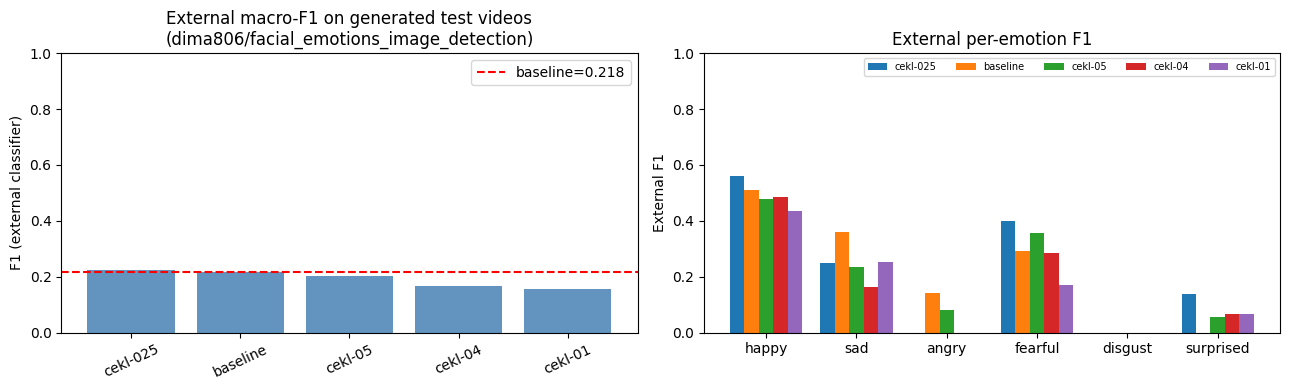


=== External confusion matrices (rows = true, cols = predicted) ===

baseline
           happy  sad  angry  fearful  disgust  surprised
happy         23    1      0        0        0          0
sad            9   14      0        1        0          0
angry          8   10      2        2        0          2
fearful        5   11      1        6        0          1
disgust        9   11      1        3        0          0
surprised     12    7      0        5        0          0

cekl-025
           happy  sad  angry  fearful  disgust  surprised
happy         21    2      0        0        0          1
sad            7    8      3        6        0          0
angry          7    8      0        7        0          2
fearful        2    4      6       12        0          0
disgust        5   12      2        5        0          0
surprised      9    6      1        6        0          2


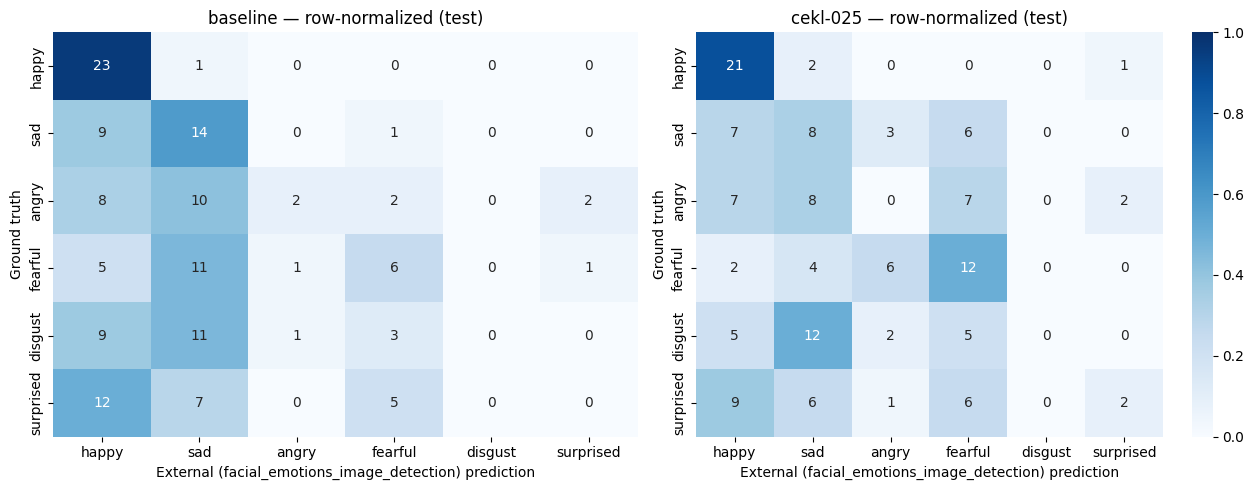

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot: external F1 per config, per-emotion breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
names = summary_df["config"].tolist()

axes[0].bar(names, summary_df["ext_F1_macro"], color="steelblue", alpha=0.85)
axes[0].axhline(base_f1, color="red", ls="--", label=f"baseline={base_f1:.3f}")
axes[0].set_title(f"External macro-F1 on generated test videos\n({EXT_VIDEO_MODEL})")
axes[0].set_ylabel("F1 (external classifier)")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend()

x = np.arange(NUM_EMO)
w = 0.8 / len(names)
for i, n in enumerate(names):
    vals = [summary_df.loc[summary_df["config"] == n, f"ext_F1_{e}"].iloc[0] for e in EMOTIONS]
    axes[1].bar(x + (i - len(names) / 2 + 0.5) * w, vals, w, label=n)
axes[1].set_xticks(x)
axes[1].set_xticklabels(EMOTIONS)
axes[1].set_ylabel("External F1")
axes[1].set_ylim(0, 1)
axes[1].set_title("External per-emotion F1")
axes[1].legend(fontsize=7, ncol=len(names))
plt.tight_layout()
plt.show()

# Confusion matrices: baseline vs best (side-by-side, row-normalized).
# Baseline shows the underlying emotion recoverability of un-fine-tuned generations;
# best shows where the emotion-aware loss redistributes errors.
best_name_ext = summary_df.iloc[0]["config"]
baseline_df_ext = per_model["baseline"] if "baseline" in per_model else None
best_df_ext = per_model[best_name_ext]

cm_pairs = []
if baseline_df_ext is not None and best_name_ext != "baseline":
    cm_pairs.append(("baseline", baseline_df_ext))
cm_pairs.append((best_name_ext, best_df_ext))

print("\n=== External confusion matrices (rows = true, cols = predicted) ===")
for title, dfm in cm_pairs:
    cm = confusion_matrix(dfm["emotion_true"], dfm["ext_pred"], labels=list(range(NUM_EMO)))
    print(f"\n{title}")
    print(pd.DataFrame(cm, index=EMOTIONS, columns=EMOTIONS).to_string())

fig_cm, axes_cm = plt.subplots(1, len(cm_pairs), figsize=(6.5 * len(cm_pairs), 5),
                                 squeeze=False)
for col, (title, dfm) in enumerate(cm_pairs):
    cm = confusion_matrix(dfm["emotion_true"], dfm["ext_pred"], labels=list(range(NUM_EMO)))
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    ax = axes_cm[0, col]
    sns.heatmap(cm_norm, annot=cm, fmt="d",
                cmap="Blues", vmin=0, vmax=1,
                xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax,
                cbar=(col == len(cm_pairs) - 1))
    ax.set_xlabel(f"External ({EXT_VIDEO_MODEL.split('/')[-1]}) prediction")
    ax.set_ylabel("Ground truth")
    ax.set_title(f"{title} — row-normalized (test)")
plt.tight_layout()
plt.show()

## Optional: dimensional audio check (MSP-Podcast wav2vec2)

Second external perspective — valence/arousal on the *original* audio. Used only to confirm that our test-split emotion labels align with what an independent audio model perceives. Not used to score generation (generation is video-only).

In [12]:
RUN_AUDIO_SANITY = True

if RUN_AUDIO_SANITY:
    # The audeering MSP-DIM model uses a custom regression head that AutoModel does NOT load
    # (it would silently return base wav2vec2 hidden states instead of arousal/dominance/valence).
    # Per the model card, we have to define the head and wrap a Wav2Vec2Model ourselves.
    from transformers import Wav2Vec2Processor, Wav2Vec2Model, Wav2Vec2PreTrainedModel

    EXT_AUDIO_MODEL = "audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim"

    class _RegressionHead(nn.Module):
        def __init__(self, config):
            super().__init__()
            self.dense = nn.Linear(config.hidden_size, config.hidden_size)
            self.dropout = nn.Dropout(config.final_dropout)
            self.out_proj = nn.Linear(config.hidden_size, config.num_labels)

        def forward(self, x):
            x = self.dropout(x)
            x = self.dense(x)
            x = torch.tanh(x)
            x = self.dropout(x)
            return self.out_proj(x)

    class _AudeeringEmotionModel(Wav2Vec2PreTrainedModel):
        """Mirror of the official model card snippet. Output `logits` = (arousal, dominance, valence) in [0, 1]."""

        def __init__(self, config):
            super().__init__(config)
            self.config = config
            self.wav2vec2 = Wav2Vec2Model(config)
            self.classifier = _RegressionHead(config)
            self.init_weights()

        def forward(self, input_values, attention_mask=None):
            outputs = self.wav2vec2(input_values, attention_mask=attention_mask)
            hidden = outputs[0].mean(dim=1)
            return self.classifier(hidden)  # (B, 3) — arousal, dominance, valence

    ext_audio_proc = Wav2Vec2Processor.from_pretrained(EXT_AUDIO_MODEL)
    ext_audio_model = _AudeeringEmotionModel.from_pretrained(EXT_AUDIO_MODEL).to(DEVICE).eval()
    for p in ext_audio_model.parameters():
        p.requires_grad = False
    print(f"Loaded MSP-DIM regressor: out_dim={ext_audio_model.config.num_labels} (arousal, dominance, valence)")

    @torch.no_grad()
    def audio_vad(wav_1d):
        # Audeering model expects 16 kHz mono; processor handles normalization.
        inputs = ext_audio_proc(wav_1d.numpy(), sampling_rate=SR, return_tensors="pt", padding=True)
        kwargs = {"input_values": inputs["input_values"].to(DEVICE)}
        if "attention_mask" in inputs:
            kwargs["attention_mask"] = inputs["attention_mask"].to(DEVICE)
        out = ext_audio_model(**kwargs)  # (1, 3)
        return out.squeeze(0).cpu().numpy()  # arousal, dominance, valence in [0, 1]

    rows = []
    for s in tqdm(test_ds, desc="External audio VAD"):
        a, d, val = audio_vad(s["audio"])
        rows.append({"emotion": EMOTIONS[s["emotion"]],
                     "arousal": float(a),
                     "dominance": float(d),
                     "valence": float(val)})
    vad_df = pd.DataFrame(rows)
    print("\n=== Ground-truth audio VAD (MSP-Podcast model, scores in [0, 1]) ===")
    print(vad_df.groupby("emotion")[["arousal", "dominance", "valence"]].mean().round(3))
    print("\nExpected (if labels agree with perception):")
    print("  happy     — high valence, mid-high arousal")
    print("  sad       — low valence, low arousal")
    print("  angry     — low valence, high arousal, high dominance")
    print("  fearful   — low valence, high arousal, low dominance")
    print("  disgust   — low valence, mid-low arousal")
    print("  surprised — mid-high valence, high arousal")
    vad_df.to_csv(OUT_DIR / "audio_vad.csv", index=False)

    del ext_audio_model
    torch.cuda.empty_cache()

preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/661M [00:00<?, ?B/s]

Loaded MSP-DIM regressor: out_dim=3 (arousal, dominance, valence)


External audio VAD: 100%|██████████| 144/144 [00:37<00:00,  3.88it/s]


=== Ground-truth audio VAD (MSP-Podcast model, scores in [0, 1]) ===
           arousal  dominance  valence
emotion                               
angry        0.753      0.775    0.251
disgust      0.573      0.631    0.294
fearful      0.605      0.624    0.345
happy        0.627      0.659    0.345
sad          0.439      0.521    0.353
surprised    0.659      0.689    0.341

Expected (if labels agree with perception):
  happy     — high valence, mid-high arousal
  sad       — low valence, low arousal
  angry     — low valence, high arousal, high dominance
  fearful   — low valence, high arousal, low dominance
  disgust   — low valence, mid-low arousal
  surprised — mid-high valence, high arousal


## Thesis-ready combined table

Merges internal-encoder F1 (from `04_finetune_wav2lip.ipynb` selection table)
with external-classifier F1 from this notebook — the side-by-side answer to
"does external evaluation confirm the gains?". Fill `INTERNAL_VAL_F1` below
from `04` cell 8's `best_f1` column for matching `name`.

In [13]:
# Fill internal val F1 from 04 cell 8 selection table (best_f1 per config).
# Keys must match CHECKPOINTS names in cell 4.
INTERNAL_VAL_F1 = {
    "baseline": 0.434,
    "cekl-01":  0.512,
    "cekl-025": 0.511,
    "cekl-04":  0.496,
    "cekl-05":  0.465,
}

# Dynamic column set — adapts to whatever EMOTIONS is defined in cell 2.
ext_cols = [f"ext_F1_{e}" for e in EMOTIONS]

combined = summary_df[["config", "ext_accuracy", "ext_F1_macro",
                       *ext_cols, "Δ_F1_vs_baseline"]].copy()
combined["internal_val_F1"] = combined["config"].map(INTERNAL_VAL_F1)
combined = combined[["config", "internal_val_F1", "ext_F1_macro", "Δ_F1_vs_baseline",
                     "ext_accuracy", *ext_cols]]
print("\n=== Internal vs External F1 (for thesis table) ===")
print(combined.to_string(index=False))
combined.to_csv(OUT_DIR / "internal_vs_external.csv", index=False)


=== Internal vs External F1 (for thesis table) ===
  config  internal_val_F1  ext_F1_macro  Δ_F1_vs_baseline  ext_accuracy  ext_F1_happy  ext_F1_sad  ext_F1_angry  ext_F1_fearful  ext_F1_disgust  ext_F1_surprised
cekl-025            0.511      0.224655          0.007051      0.298611      0.560000    0.250000      0.000000        0.400000             0.0          0.137931
baseline            0.434      0.217604          0.000000      0.312500      0.511111    0.358974      0.142857        0.292683             0.0          0.000000
 cekl-05            0.465      0.201193         -0.016411      0.284722      0.479167    0.235294      0.080000        0.357143             0.0          0.055556
 cekl-04            0.496      0.166861         -0.050744      0.256944      0.484848    0.163934      0.000000        0.285714             0.0          0.066667
 cekl-01            0.512      0.154738         -0.062866      0.250000      0.436364    0.253968      0.000000        0.171429           